# 06 Error Slicing

This notebook examines the prediction errors of the selected model across different customer subgroups.

While global evaluation metrics provide an overall view of model performance, they can hide differences between customer segments. Error slicing helps identify groups where the model performs particularly well or poorly.

It helps answer questions such as:

- Does the model identify potential subscribers equally well across customer groups?  
- Are prediction errors concentrated in specific customer segments?  
- Do combinations of customer characteristics reveal patterns that are not visible when analyzing a single feature?  


## Slicing Scope

We use the saved predictions from the XGBoost tuning notebook and focus on the selected model: `XGBoost default`.

The error analysis focuses on a small set of customer and campaign variables that are easy to interpret from a business perspective. These variables were selected to explore whether model performance differs across meaningful customer groups.

Single slices:

- `job`
- `marital`
- `education`
- `contact`
- `month`
- `poutcome`

Selected cross-classifications:

- `job` x `education`
- `contact` x `month`
- `poutcome` x `contact`

Single-feature diagnostics provide the main overview, while cross-classifications are used to investigate whether combinations of variables reveal additional patterns. Small groups can produce unstable metrics, so a minimum group-size threshold is applied throughout the analysis.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 160)

MIN_GROUP_SIZE = 30
SELECTED_MODEL_NAME = "XGBoost default"

GOOD_METRICS = {"accuracy", "precision", "recall", "f1"}
RISK_METRICS = {"false_negative_rate", "false_positive_rate"}


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "reports" / "model_results").exists():
            return path
    raise FileNotFoundError("Could not find project root with reports/model_results.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model results directory: {MODEL_RESULTS_DIR}")


Project root: /home/patri/master/ads2-bank-marketing-project
Model results directory: /home/patri/master/ads2-bank-marketing-project/reports/model_results


## 2. Load Selected Model Predictions

In [2]:
xgboost_predictions = pd.read_csv(MODEL_RESULTS_DIR / "05_xgboost_tuning_predictions.csv")

predictions = xgboost_predictions[
    xgboost_predictions["model_name"].eq(SELECTED_MODEL_NAME)
].copy()

if predictions.empty:
    available_models = sorted(xgboost_predictions["model_name"].dropna().unique())
    raise ValueError(
        f"No predictions found for {SELECTED_MODEL_NAME!r}. "
        f"Available models: {available_models}"
    )

print(predictions["model_name"].value_counts())
predictions.head()


model_name
XGBoost default    9043
Name: count, dtype: int64


,model_name,row_id,age,job,marital,education,balance,housing,loan,contact,month,campaign,pdays,previous,poutcome,y,y_binary,PreviouslyContacted,HasAnyLoan,BalanceGroup,y_true,y_pred,subscription_probability
0,XGBoost default,0,40,blue-collar,married,primary,640,yes,yes,unknown,may,2,-1,0,unknown,no,0,0,1,Low,0,0,0.017508
1,XGBoost default,1,44,technician,married,secondary,378,yes,no,unknown,may,2,-1,0,unknown,no,0,0,1,Low,0,0,0.038485
2,XGBoost default,2,31,services,married,secondary,356,yes,no,unknown,jun,5,-1,0,unknown,no,0,0,1,Low,0,0,0.046479
3,XGBoost default,3,36,blue-collar,married,primary,655,yes,no,unknown,may,4,-1,0,unknown,no,0,0,1,Low,0,0,0.041792
4,XGBoost default,4,34,services,single,secondary,1921,yes,no,cellular,feb,1,-1,0,unknown,no,0,0,1,Medium,0,0,0.129945


#### Key Observations

- Predictions generated in the previous notebook were loaded successfully.
- The analysis focuses only on the selected model (`XGBoost default`).
- A total of 9,043 test observations are available for the error slicing analysis.
- The prediction dataset contains both the model outputs (`y_true`, `y_pred`, and `subscription_probability`) and the customer metadata required for subgroup analysis.>

In [3]:
required_columns = {
    "model_name",
    "row_id",
    "job",
    "marital",
    "education",
    "contact",
    "month",
    "poutcome",
    "y_true",
    "y_pred",
    "subscription_probability",
}

missing_columns = required_columns - set(predictions.columns)
if missing_columns:
    raise ValueError(f"Missing columns for error slicing: {sorted(missing_columns)}")

print("All required columns are available.")


All required columns are available.


## 3. Add Error Labels

To analyze model performance across different customer groups, each prediction is first classified according to its outcome.

Each observation is assigned to one of four categories:

- True Positive
- True Negative
- False Positive
- False Negative

These labels provide the foundation for the error slicing analysis in the following sections.

In [5]:
def classify_error(row: pd.Series) -> str:
    if row["y_true"] == 1 and row["y_pred"] == 1:
        return "true_positive"
    if row["y_true"] == 0 and row["y_pred"] == 0:
        return "true_negative"
    if row["y_true"] == 0 and row["y_pred"] == 1:
        return "false_positive"
    if row["y_true"] == 1 and row["y_pred"] == 0:
        return "false_negative"
    return "unknown"


predictions["error_type"] = predictions.apply(classify_error, axis=1)

predictions[
    [
        "row_id",
        "y_true",
        "y_pred",
        "subscription_probability",
        "error_type",
        "BalanceGroup",
    ]
].head()


,row_id,y_true,y_pred,subscription_probability,error_type,BalanceGroup
0,0,0,0,0.017508,true_negative,Low
1,1,0,0,0.038485,true_negative,Low
2,2,0,0,0.046479,true_negative,Low
3,3,0,0,0.041792,true_negative,Low
4,4,0,0,0.129945,true_negative,Medium


#### Key Observations

- Each prediction is assigned to one of the four standard classification outcomes.
- The new `error_type` column makes it possible to analyze where the model makes correct predictions and where it makes mistakes.
- The prediction table also retains customer information, allowing error patterns to be explored across different customer groups.

## 4. Global Metrics

Before analyzing individual customer groups, it is useful to establish the overall performance of the selected model.  

These global metrics provide a reference point for comparing performance across different segments in the following sections.

In [6]:
def calculate_metrics(df: pd.DataFrame) -> dict:
    y_true = df["y_true"]
    y_pred = df["y_pred"]

    positives = int((y_true == 1).sum())
    negatives = int((y_true == 0).sum())
    false_negatives = int(((y_true == 1) & (y_pred == 0)).sum())
    false_positives = int(((y_true == 0) & (y_pred == 1)).sum())

    return {
        "n": len(df),
        "subscription_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_negative_rate": false_negatives / positives if positives else np.nan,
        "false_positive_rate": false_positives / negatives if negatives else np.nan,
        "avg_subscription_probability": df["subscription_probability"].mean(),
    }


global_metrics = pd.DataFrame([{ "model_name": SELECTED_MODEL_NAME, **calculate_metrics(predictions)}])
global_metrics.round(4)


,model_name,n,subscription_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_subscription_probability
0,XGBoost default,9043,0.117,0.8934,0.5983,0.2703,0.3724,0.7297,0.024,0.1155


#### Key Observations

- The selected model achieves an overall accuracy of **89.34%** on the test set.
- The subscription rate is **11.7%**, confirming that the target variable is imbalanced.
- The model has relatively high precision (**59.83%**) but low recall (**27.03%**), indicating that many actual subscribers are not identified.
- The high false negative rate (**72.97%**) suggests that error slicing may help identify customer groups where these missed subscriptions are concentrated.

## Interpreting Precision, Recall, and F1

For subscription prediction, these metrics answer different questions:

- **Precision:** Of all customers predicted to subscribe, how many actually subscribed? Low precision means the model produces many false positives.
- **Recall:** Of all customers who actually subscribed, how many did the model identify? Low recall means many potential subscribers are missed.
- **F1:** A balanced measure that combines precision and recall. It is useful when both false positives and false negatives are important.

In the error slicing analysis, these metrics help identify whether certain customer groups are associated with more missed subscriptions (low recall) or less reliable positive predictions (low precision).

## 5. Single-Slice Metrics

In [7]:
SLICE_COLUMNS = [
    "job",
    "marital",
    "education",
    "contact",
    "month",
    "BalanceGroup",
]


def calculate_slice_metrics(df: pd.DataFrame, slice_column: str) -> pd.DataFrame:
    rows = []
    for slice_value, group in df.groupby(slice_column, dropna=False):
        rows.append({
            "slice_column": slice_column,
            "slice_value": str(slice_value),
            "model_name": SELECTED_MODEL_NAME,
            **calculate_metrics(group),
        })
    return pd.DataFrame(rows)


slice_metrics = pd.concat(
    [calculate_slice_metrics(predictions, column) for column in SLICE_COLUMNS],
    ignore_index=True,
)

slice_metrics.head()


,slice_column,slice_value,model_name,n,subscription_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_subscription_probability
0,job,admin.,XGBoost default,1030,0.118447,0.883495,0.516667,0.254098,0.340659,0.745902,0.031938,0.121315
1,job,blue-collar,XGBoost default,1902,0.072029,0.936383,0.750000,0.175182,0.284024,0.824818,0.004533,0.072555
2,job,entrepreneur,XGBoost default,301,0.073090,0.930233,0.666667,0.090909,0.160000,0.909091,0.003584,0.078063
3,job,housemaid,XGBoost default,227,0.105727,0.903084,0.600000,0.250000,0.352941,0.750000,0.019704,0.084429
4,job,management,XGBoost default,1947,0.133539,0.881356,0.630631,0.269231,0.377358,0.730769,0.024303,0.127456


In [9]:
slice_metrics.sort_values(
    ["false_negative_rate", "n"],
    ascending=[False, False],
).round(4).head(20)


,slice_column,slice_value,model_name,n,subscription_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_subscription_probability
21,contact,unknown,XGBoost default,2634,0.0391,0.9613,0.5714,0.0388,0.0727,0.9612,0.0012,0.0415
2,job,entrepreneur,XGBoost default,301,0.0731,0.9302,0.6667,0.0909,0.1600,0.9091,0.0036,0.0781
30,month,may,XGBoost default,2704,0.0688,0.9360,0.7241,0.1129,0.1953,0.8871,0.0032,0.0658
37,BalanceGroup,Negative,XGBoost default,1470,0.0728,0.9279,0.5185,0.1308,0.2090,0.8692,0.0095,0.0688
27,month,jul,XGBoost default,1358,0.0839,0.9205,0.6154,0.1404,0.2286,0.8596,0.0080,0.0887
1,job,blue-collar,XGBoost default,1902,0.0720,0.9364,0.7500,0.1752,0.2840,0.8248,0.0045,0.0726
28,month,jun,XGBoost default,1104,0.0951,0.8940,0.3800,0.1810,0.2452,0.8190,0.0310,0.1022
23,month,aug,XGBoost default,1261,0.1134,0.8961,0.6500,0.1818,0.2842,0.8182,0.0125,0.1093
15,education,primary,XGBoost default,1320,0.0864,0.9182,0.5789,0.1930,0.2895,0.8070,0.0133,0.0816
31,month,nov,XGBoost default,827,0.1052,0.9033,0.6207,0.2069,0.3103,0.7931,0.0149,0.0955


#### Key Observations

- The table ranks customer groups by their false negative rate, highlighting where the model misses the highest proportion of actual subscribers.
- Several groups show substantially higher false negative rates than others, suggesting that model performance is not uniform across all customer segments.
- These results provide a starting point for the more detailed subgroup analyses in the following sections.

## 6. Single-Slice Diagnostics

Bar charts provide an intuitive way to compare model performance across different customer groups.  

Each chart displays the selected evaluation metrics for one customer characteristic. Green bars indicate stronger performance, while red bars highlight weaker performance.  

These visualizations make it easier to identify customer groups where the model performs particularly well or where additional improvements may be needed.  

In [10]:
def metric_colormap(metric: str) -> str:
    if metric in GOOD_METRICS:
        return "RdYlGn"
    if metric in RISK_METRICS:
        return "RdYlGn_r"
    return "viridis"


def metric_label(metric: str) -> str:
    return metric.replace("_", " ").title()


def bar_color(values: pd.Series, metric: str):
    cmap = plt.get_cmap(metric_colormap(metric))
    normalized = values.clip(lower=0, upper=1).fillna(0)
    return [cmap(value) for value in normalized]


def plot_single_slice_bars(
    metrics_df: pd.DataFrame,
    slice_column: str,
    metrics: list[str],
    min_group_size: int = MIN_GROUP_SIZE,
) -> None:
    plot_df = metrics_df[
        (metrics_df["slice_column"] == slice_column)
        & (metrics_df["n"] >= min_group_size)
    ].copy()

    if plot_df.empty:
        print(f"No groups with n >= {min_group_size} for {slice_column}.")
        return

    plot_df = plot_df.sort_values("recall")
    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(4.8 * len(metrics), max(3, 0.55 * len(plot_df))),
        sharey=True,
        squeeze=False,
    )

    y_positions = np.arange(len(plot_df))

    for ax, metric in zip(axes[0], metrics):
        values = plot_df[metric]
        ax.barh(y_positions, values, color=bar_color(values, metric), edgecolor="white")
        ax.set_title(metric_label(metric))
        ax.set_xlim(0, 1)
        ax.set_xlabel("Score")
        ax.grid(axis="x", alpha=0.25)

        for y_pos, value, count in zip(y_positions, values, plot_df["n"]):
            label = "n/a" if pd.isna(value) else f"{value:.2f} | n={int(count)}"
            ax.text(min(value + 0.02, 0.98) if pd.notna(value) else 0.02, y_pos, label, va="center", fontsize=8)

    axes[0][0].set_yticks(y_positions)
    axes[0][0].set_yticklabels(plot_df["slice_value"])
    fig.suptitle(f"{slice_column} slices", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


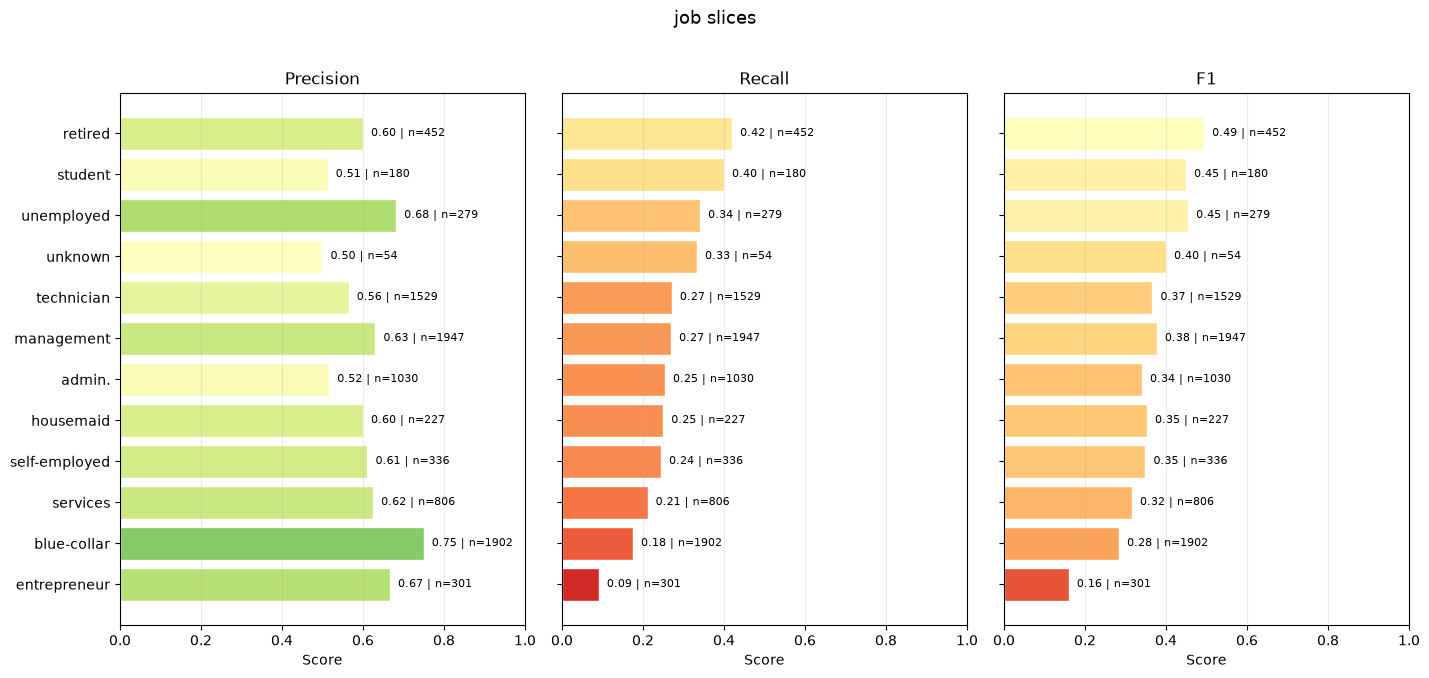

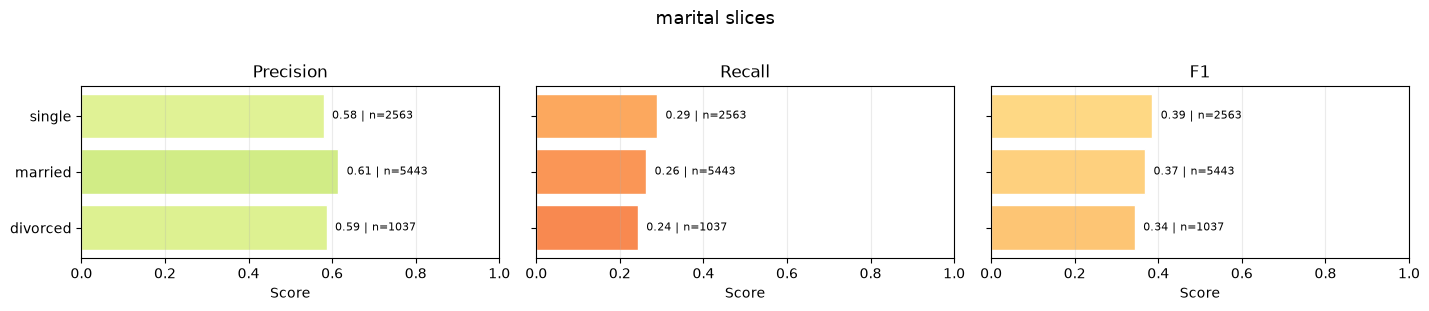

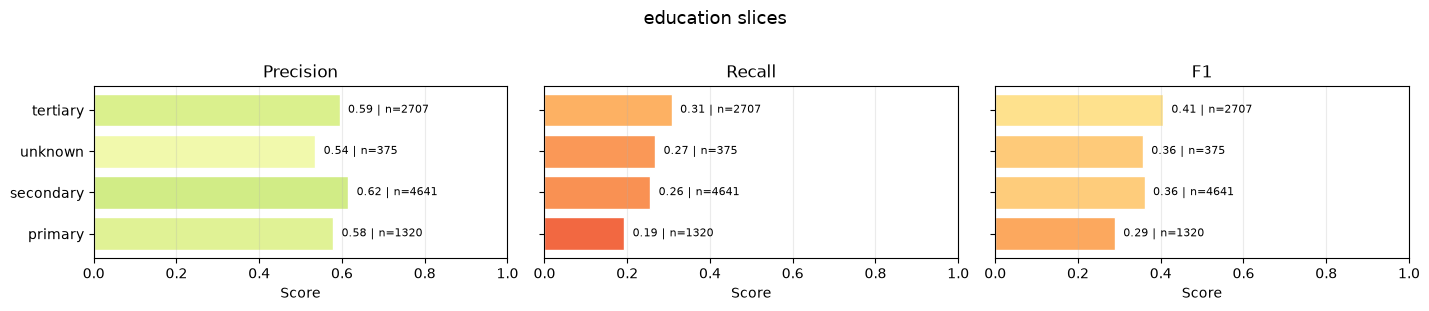

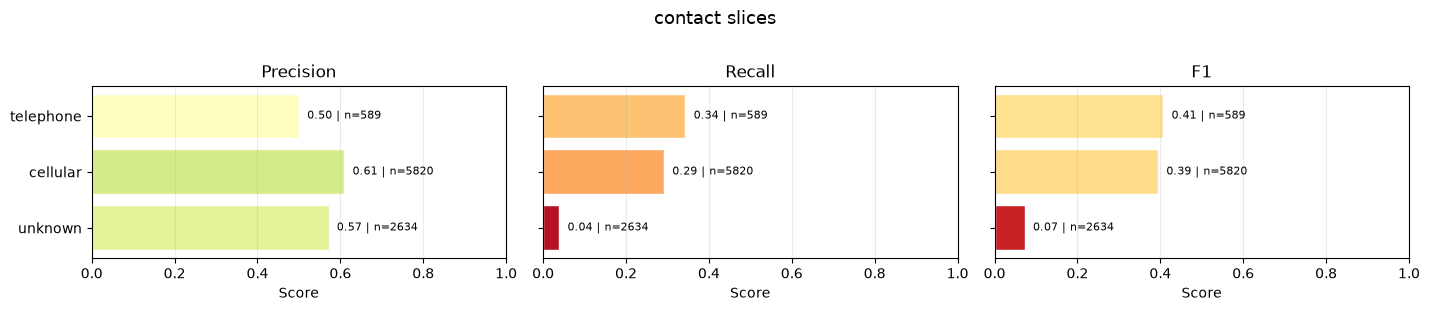

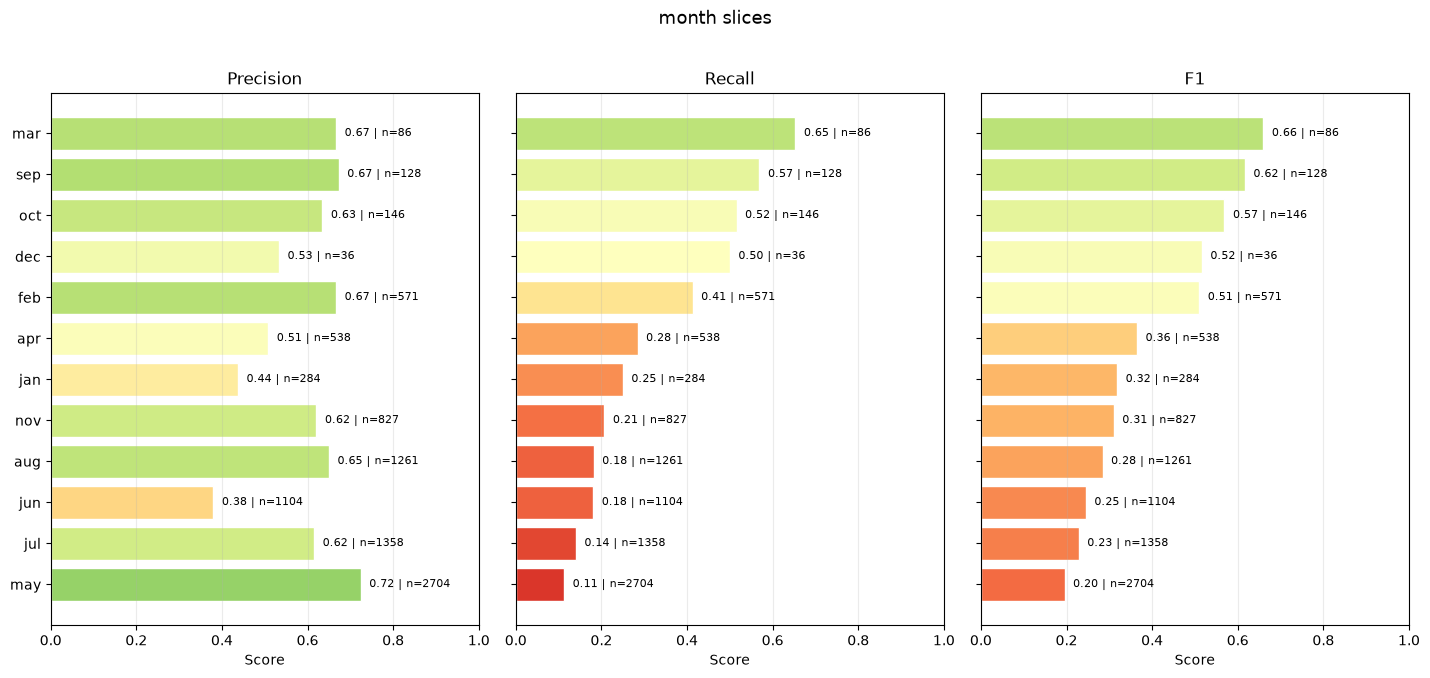

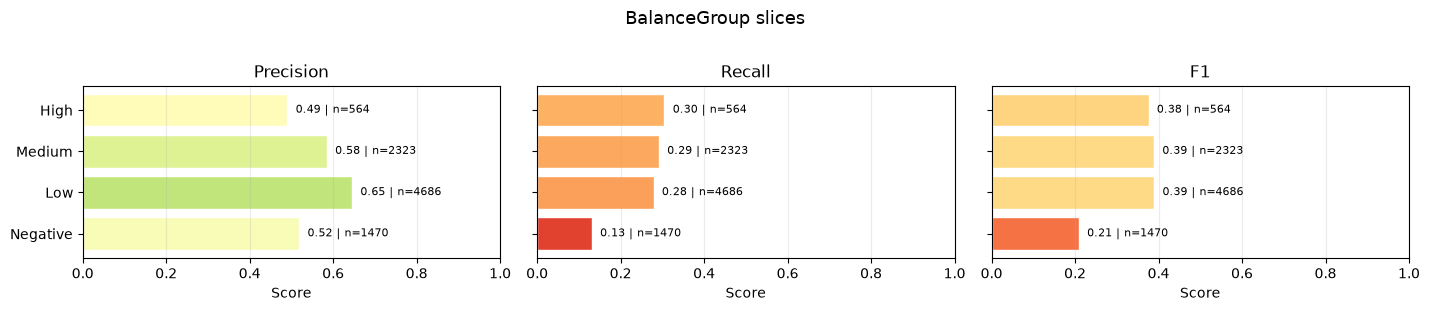

In [11]:
for column in ["job","marital","education","contact","month","BalanceGroup",]:
    plot_single_slice_bars(
        slice_metrics,
        column,
        metrics=["precision", "recall", "f1"],
    )


#### Key Observations

- Model performance varies across customer groups, confirming that the overall metrics hide important differences.
- The model performs best for retired customers, while entrepreneur customers show the lowest recall and F1 scores among the job categories.
- Customers with an unknown contact type exhibit particularly poor performance, with very low recall and F1.
- Performance also varies across campaign months and balance groups, suggesting that customer characteristics influence prediction quality.

## 7. Cross-Classification Metrics

In [12]:
CROSS_SLICE_PAIRS = [
    ("job", "education"),
    ("contact", "month"),
    ("poutcome", "contact"),
]


def calculate_cross_slice_metrics(df: pd.DataFrame, row_column: str, column_column: str) -> pd.DataFrame:
    rows = []
    for (row_value, column_value), group in df.groupby([row_column, column_column], dropna=False):
        rows.append({
            "row_column": row_column,
            "column_column": column_column,
            "row_value": str(row_value),
            "column_value": str(column_value),
            "model_name": SELECTED_MODEL_NAME,
            **calculate_metrics(group),
        })
    return pd.DataFrame(rows)


cross_slice_metrics = pd.concat(
    [calculate_cross_slice_metrics(predictions, row_col, col_col) for row_col, col_col in CROSS_SLICE_PAIRS],
    ignore_index=True,
)

cross_slice_metrics.head()


,row_column,column_column,row_value,column_value,model_name,n,subscription_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_subscription_probability
0,job,education,admin.,primary,XGBoost default,42,0.095238,0.904762,0.000000,0.000000,0.000000,1.000000,0.000000,0.052220
1,job,education,admin.,secondary,XGBoost default,816,0.111520,0.890931,0.525000,0.230769,0.320611,0.769231,0.026207,0.113301
2,job,education,admin.,tertiary,XGBoost default,136,0.161765,0.830882,0.473684,0.409091,0.439024,0.590909,0.087719,0.195255
3,job,education,admin.,unknown,XGBoost default,36,0.138889,0.888889,1.000000,0.200000,0.333333,0.800000,0.000000,0.104235
4,job,education,blue-collar,primary,XGBoost default,711,0.050633,0.952180,0.666667,0.111111,0.190476,0.888889,0.002963,0.058453


In [13]:
cross_slice_metrics.sort_values(
    ["recall", "n"],
    ascending=[True, False],
).round(4).head(20)


,row_column,column_column,row_value,column_value,model_name,n,subscription_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_subscription_probability
80,contact,month,unknown,may,XGBoost default,1593,0.0282,0.9718,0.0,0.0,0.0,1.0,0.0000,0.0331
78,contact,month,unknown,jun,XGBoost default,937,0.0448,0.9552,0.0,0.0,0.0,1.0,0.0000,0.0455
40,job,education,unemployed,primary,XGBoost default,64,0.1094,0.8750,0.0,0.0,0.0,1.0,0.0175,0.0872
77,contact,month,unknown,jul,XGBoost default,54,0.0185,0.9815,0.0,0.0,0.0,1.0,0.0000,0.0558
61,contact,month,telephone,aug,XGBoost default,46,0.0870,0.8913,0.0,0.0,0.0,1.0,0.0238,0.0995
0,job,education,admin.,primary,XGBoost default,42,0.0952,0.9048,0.0,0.0,0.0,1.0,0.0000,0.0522
8,job,education,entrepreneur,primary,XGBoost default,39,0.0513,0.9487,0.0,0.0,0.0,1.0,0.0000,0.0703
36,job,education,technician,primary,XGBoost default,28,0.0000,1.0000,0.0,0.0,0.0,NaN,0.0000,0.0602
24,job,education,self-employed,primary,XGBoost default,26,0.0385,0.8846,0.0,0.0,0.0,1.0,0.0800,0.1201
47,job,education,unknown,unknown,XGBoost default,24,0.1250,0.8750,0.0,0.0,0.0,1.0,0.0000,0.0647


#### Key Observations

- Cross-slice metrics evaluate combinations of two customer characteristics rather than individual variables.
- Several combinations show very low recall and F1 scores; however, many of these groups contain only a small number of observations.
- Small subgroup sizes can produce unstable performance estimates, so these results should be interpreted with caution.
- The following visualizations apply a minimum group-size threshold to focus on more reliable subgroup comparisons.

## 8. Selected Cross-Classification Heatmaps

The cross-classification view is intentionally limited.

The one-dimensional slice analysis already highlights the main performance patterns. Here we inspect a small number of meaningful combinations of customer and campaign characteristics, focusing on **recall**: among customers who actually subscribed, how many does the model correctly identify?

Low recall is shown in red because it indicates many missed subscriptions, while high recall is shown in green. Each cell also displays the number of observations in the corresponding subgroup.

Precision and F1 remain available in the saved cross-slice metrics table, but plotting every metric for every combination would make the notebook unnecessarily difficult to interpret.

In [14]:
def plot_cross_metric_heatmap(
    metrics_df: pd.DataFrame,
    row_column: str,
    column_column: str,
    metric: str,
    min_group_size: int = MIN_GROUP_SIZE,
) -> None:
    plot_df = metrics_df[
        (metrics_df["row_column"] == row_column)
        & (metrics_df["column_column"] == column_column)
    ].copy()

    value_pivot = plot_df.pivot(index="row_value", columns="column_value", values=metric)
    count_pivot = plot_df.pivot(index="row_value", columns="column_value", values="n")

    value_pivot = value_pivot.where(count_pivot >= min_group_size)

    fig_width = max(7, 1.5 * len(value_pivot.columns))
    fig_height = max(3.5, 0.75 * len(value_pivot.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    matrix = value_pivot.to_numpy(dtype=float)
    image = ax.imshow(matrix, aspect="auto", cmap=metric_colormap(metric), vmin=0, vmax=1)

    ax.set_title(f"{metric_label(metric)} by {row_column} and {column_column}")
    ax.set_xlabel(column_column)
    ax.set_ylabel(row_column)
    ax.set_xticks(np.arange(len(value_pivot.columns)))
    ax.set_xticklabels(value_pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(value_pivot.index)))
    ax.set_yticklabels(value_pivot.index)

    for row_idx, row_value in enumerate(value_pivot.index):
        for col_idx, col_value in enumerate(value_pivot.columns):
            count = count_pivot.loc[row_value, col_value]
            value = value_pivot.loc[row_value, col_value]
            if pd.isna(value):
                label = f"n={int(count)}" if pd.notna(count) else "n/a"
            else:
                label = f"{value:.2f}\nn={int(count)}"
            ax.text(col_idx, row_idx, label, ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, label=metric_label(metric))
    plt.tight_layout()
    plt.show()


def plot_cross_heatmap_matrix(
    metrics_df: pd.DataFrame,
    row_column: str,
    column_column: str,
    metrics: list[str],
    min_group_size: int = MIN_GROUP_SIZE,
) -> None:
    for metric in metrics:
        plot_cross_metric_heatmap(
            metrics_df,
            row_column=row_column,
            column_column=column_column,
            metric=metric,
            min_group_size=min_group_size,
        )


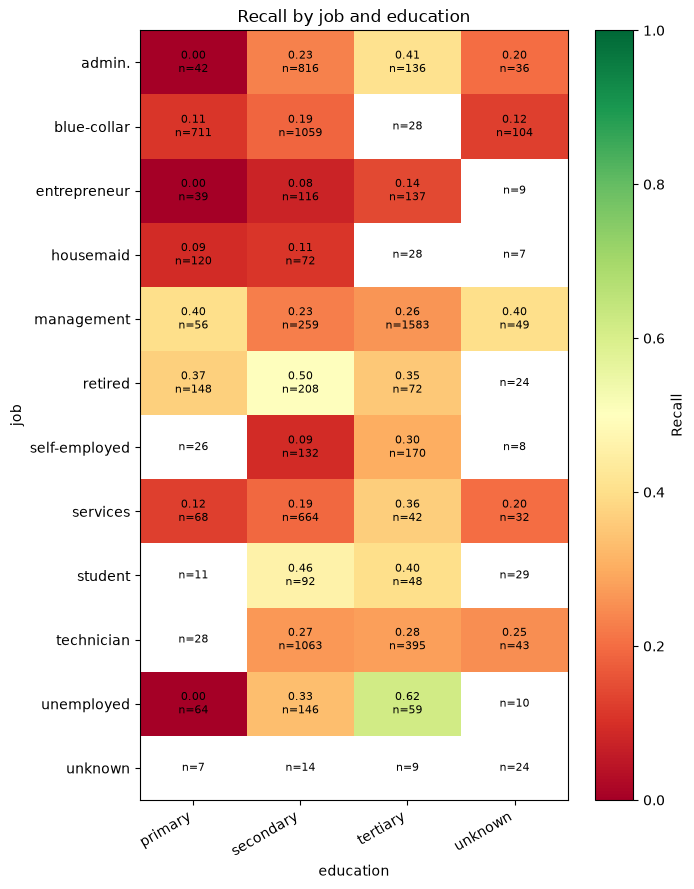

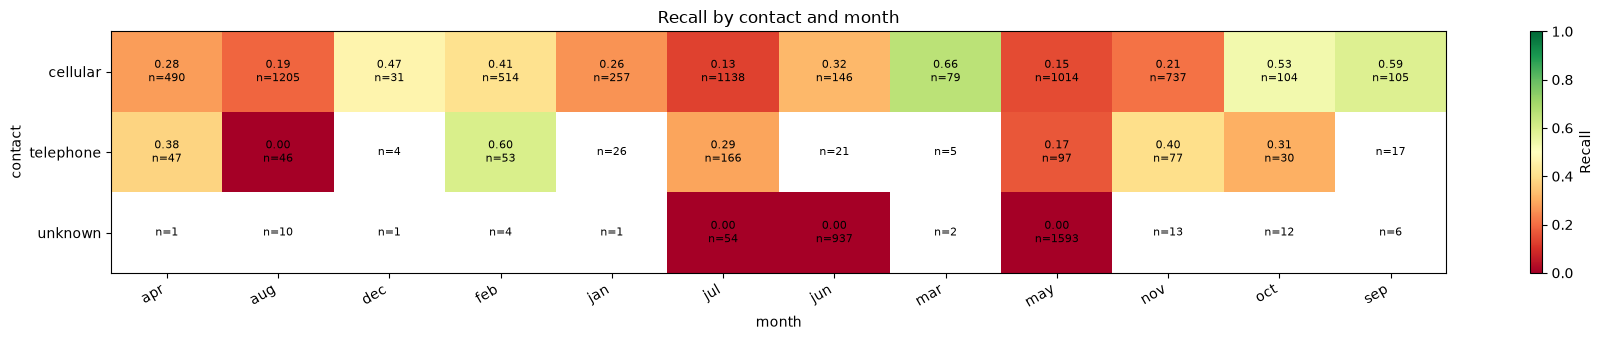

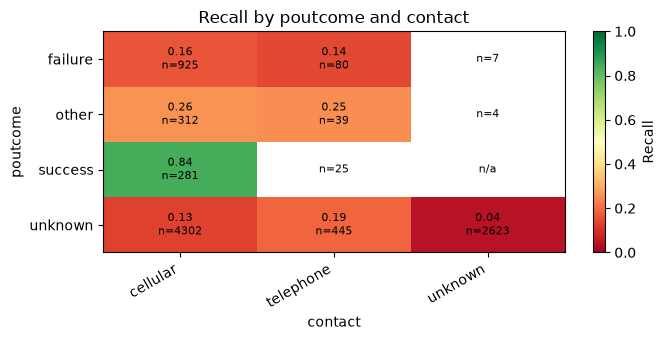

In [15]:
for row_column, column_column in CROSS_SLICE_PAIRS:
    plot_cross_metric_heatmap(
        cross_slice_metrics,
        row_column=row_column,
        column_column=column_column,
        metric="recall",
    )


#### Key Observations

- The model identifies a higher proportion of actual subscribers in some customer groups than in others, showing that performance is not uniform across the dataset.
- Entrepreneur customers are consistently associated with low recall, meaning that the model misses many customers who actually subscribe within this group.
- Customers contacted through an unknown channel also show very low recall across several campaign months, indicating that many actual subscribers are not identified.
- Some combinations perform considerably better. For example, customers with a successful previous campaign who were contacted by cellular phone achieve much higher recall, meaning the model correctly identifies most actual subscribers in this segment.
- Empty cells correspond to groups with too few observations and should not be interpreted because the estimates would not be reliable.

## 9. Cross-Slices to Inspect First

In [16]:
inspection_candidates = cross_slice_metrics[
    cross_slice_metrics["n"] >= MIN_GROUP_SIZE
].copy()

inspection_candidates = inspection_candidates.sort_values(
    ["recall", "precision", "n"],
    ascending=[True, True, False],
)

inspection_candidates[
    [
        "row_column",
        "column_column",
        "row_value",
        "column_value",
        "n",
        "subscription_rate",
        "precision",
        "recall",
        "f1",
        "false_negative_rate",
        "false_positive_rate",
        "avg_subscription_probability",
    ]
].round(4).head(20)


,row_column,column_column,row_value,column_value,n,subscription_rate,precision,recall,f1,false_negative_rate,false_positive_rate,avg_subscription_probability
80,contact,month,unknown,may,1593,0.0282,0.0000,0.0000,0.0000,1.0000,0.0000,0.0331
78,contact,month,unknown,jun,937,0.0448,0.0000,0.0000,0.0000,1.0000,0.0000,0.0455
40,job,education,unemployed,primary,64,0.1094,0.0000,0.0000,0.0000,1.0000,0.0175,0.0872
77,contact,month,unknown,jul,54,0.0185,0.0000,0.0000,0.0000,1.0000,0.0000,0.0558
61,contact,month,telephone,aug,46,0.0870,0.0000,0.0000,0.0000,1.0000,0.0238,0.0995
0,job,education,admin.,primary,42,0.0952,0.0000,0.0000,0.0000,1.0000,0.0000,0.0522
8,job,education,entrepreneur,primary,39,0.0513,0.0000,0.0000,0.0000,1.0000,0.0000,0.0703
94,poutcome,contact,unknown,unknown,2623,0.0385,0.5714,0.0396,0.0741,0.9604,0.0012,0.0412
9,job,education,entrepreneur,secondary,116,0.1121,0.5000,0.0769,0.1333,0.9231,0.0097,0.0766
25,job,education,self-employed,secondary,132,0.0833,0.3333,0.0909,0.1429,0.9091,0.0165,0.0671


#### Key Observations

- After removing very small groups, the table highlights the customer segments where the model misses the highest proportion of actual subscribers.
- Several combinations involving an unknown contact channel remain among the weakest-performing segments, confirming the patterns observed in the heatmaps.
- Some job and education combinations, particularly entrepreneur customers with primary education, also show very low recall, meaning that many actual subscribers are not identified.
- These ranked results provide a practical starting point for prioritizing future model improvements and further investigation.

## 10. Save Error Slicing Results

The error slicing outputs are saved as CSV files for later analysis.

Saved artifacts:

- single-slice performance metrics
- cross-slice performance metrics
- global evaluation metrics
- predictions with assigned error labels

In [17]:
slice_metrics_path = MODEL_RESULTS_DIR / "06_error_slicing_metrics.csv"
cross_slice_metrics_path = MODEL_RESULTS_DIR / "06_error_slicing_cross_metrics.csv"
global_metrics_path = MODEL_RESULTS_DIR / "06_error_slicing_global_metrics.csv"
predictions_with_errors_path = MODEL_RESULTS_DIR / "06_predictions_with_error_types.csv"

slice_metrics.to_csv(slice_metrics_path, index=False)
cross_slice_metrics.to_csv(cross_slice_metrics_path, index=False)
global_metrics.to_csv(global_metrics_path, index=False)
predictions.to_csv(predictions_with_errors_path, index=False)

print(f"Saved single-slice metrics to: {slice_metrics_path}")
print(f"Saved cross-slice metrics to: {cross_slice_metrics_path}")
print(f"Saved global metrics to: {global_metrics_path}")
print(f"Saved predictions with error labels to: {predictions_with_errors_path}")


Saved single-slice metrics to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/06_error_slicing_metrics.csv
Saved cross-slice metrics to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/06_error_slicing_cross_metrics.csv
Saved global metrics to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/06_error_slicing_global_metrics.csv
Saved predictions with error labels to: /home/patri/master/ads2-bank-marketing-project/reports/model_results/06_predictions_with_error_types.csv


## Error Slicing Summary

Error slicing extends the global evaluation by examining model performance across different customer groups.

The analysis helps answer questions such as:

- Which customer groups contain the highest proportion of missed subscribers?
- Which groups show lower prediction quality?
- Which combinations of customer characteristics are associated with weaker model performance?
- Are some results influenced by very small subgroup sizes?

The saved tables include precision, recall, F1, false negative rate, and false positive rate. The cross-classification visualizations focus on recall because they highlight where the model fails to identify customers who actually subscribe.

## Reflection: Why Some Customer Groups Are Harder

The analysis shows that model performance is not uniform across all customer groups.

Some segments contain patterns that are easier for the model to learn, while others are more difficult. As a result, certain groups have much lower recall, meaning that many customers who actually subscribe are not identified.

Possible reasons include:

- limited training examples for some customer groups
- missing or less informative features
- a global classification threshold that may not work equally well for every segment
- differences in customer behaviour across campaign groups

Possible improvements include:

- collecting more representative data
- engineering additional features
- testing different probability thresholds
- improving class imbalance handling
- exploring segment-specific modelling strategies

Error slicing helps identify these weak areas so they can be investigated in future iterations of the project.

Hyperparameter tuning produced only marginal improvements over the default XGBoost model. Error slicing revealed that the weakest performance is concentrated in customer groups with unknown contact information and specific combinations of customer characteristics. These findings suggest that future work should focus on data quality, additional feature engineering, and threshold optimization rather than further hyperparameter tuning.